In [ ]:
!pip install jinja2

In [745]:
import os
import sys
import numpy as np
import pandas as pd
import tensorflow as tf
import jinja2
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten
import matplotlib.pyplot as plt
from keras.utils import to_categorical
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, 
roc_auc_score,f1_score, confusion_matrix, roc_curve)
from tensorflow.keras.regularizers import l2, l1, l1_l2

In [820]:
# Load RNA-seq dataset
data = pd.read_csv("final_project_data.csv")
df = pd.DataFrame(data)
df.set_index('Gene ID', inplace=True)

# Extract gene name
name = df['Gene Name']
name_df = pd.DataFrame(name, columns = ['Gene Name'])
name_df

,Gene Name
Gene ID,
ENSG00000000003,TSPAN6
ENSG00000000005,TNMD
ENSG00000000419,DPM1
ENSG00000000457,SCYL3
ENSG00000000460,C1orf112
...,...
ENSG00000281918,NaN
ENSG00000281919,NaN
ENSG00000281920,NaN


In [821]:
# Format dataset
df.drop('Gene Name', axis=1, inplace=True)
df1 = df.transpose()
df1.head()

Gene ID,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000281913,ENSG00000281914,ENSG00000281915,ENSG00000281916,ENSG00000281917,ENSG00000281918,ENSG00000281919,ENSG00000281920,ENSG00000281921,ENSG00000281922
SRR5176628,480,5,347,191,55,686,1300,617,476,352,...,0,0,0,0,0,3,0,0,1,0
SRR5176629,516,4,351,242,67,143,821,758,946,376,...,0,0,0,0,0,1,0,0,0,0
SRR5176630,443,3,290,201,48,205,1194,822,882,378,...,0,0,0,0,0,3,0,0,1,0
SRR5176631,223,0,122,68,21,48,295,266,221,110,...,0,0,0,0,0,0,0,0,1,0
SRR5176632,285,2,288,220,71,224,1272,576,690,437,...,0,0,0,0,0,2,0,0,1,0


In [822]:
# Load dataset of experiment design info
exp_design = pd.read_csv("experimental_design.csv")
design_df = pd.DataFrame(exp_design)

# Get sample labels 
label_col = design_df.iloc[:,3]
#print(label_col)
label_names = label_col.values.reshape(-1)
#print(label_names)

In [823]:
# Add labels to RNA-seq data
df_labeled = df1
df_labeled.insert(0, 'Label', label_names)
df_labeled.head(5)

Gene ID,Label,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,...,ENSG00000281913,ENSG00000281914,ENSG00000281915,ENSG00000281916,ENSG00000281917,ENSG00000281918,ENSG00000281919,ENSG00000281920,ENSG00000281921,ENSG00000281922
SRR5176628,Crohn's disease,480,5,347,191,55,686,1300,617,476,...,0,0,0,0,0,3,0,0,1,0
SRR5176629,non inflammatory bowel disease control,516,4,351,242,67,143,821,758,946,...,0,0,0,0,0,1,0,0,0,0
SRR5176630,non inflammatory bowel disease control,443,3,290,201,48,205,1194,822,882,...,0,0,0,0,0,3,0,0,1,0
SRR5176631,Crohn's disease,223,0,122,68,21,48,295,266,221,...,0,0,0,0,0,0,0,0,1,0
SRR5176632,non inflammatory bowel disease control,285,2,288,220,71,224,1272,576,690,...,0,0,0,0,0,2,0,0,1,0


In [824]:
# Extract labels
labels = df_labeled.iloc[:,0]

# One hot encode labels
y = pd.get_dummies(labels, dtype='int', drop_first=True)

# Rename column to "label"
y.columns = ['label']

# Convert y to int
y['label'] = y['label'].astype(int)

In [825]:
# Get features
features = df1.iloc[:, 1:]

# Normalize by CPM + log transformation
library_sizes = features.sum(axis=1)
cpm = features.div(library_sizes, axis=0) * 1e6
log_cpm = np.log2(cpm + 1)
log_cpm.head()

Gene ID,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000281913,ENSG00000281914,ENSG00000281915,ENSG00000281916,ENSG00000281917,ENSG00000281918,ENSG00000281919,ENSG00000281920,ENSG00000281921,ENSG00000281922
SRR5176628,5.592934,0.577590,5.136247,4.308005,2.681650,6.099105,7.011361,5.948518,5.581113,5.156304,...,0.0,0.0,0.0,0.0,0.0,0.373411,0.0,0.0,0.135496,0.0
SRR5176629,5.452885,0.413366,4.912386,4.397340,2.713139,3.684982,6.110608,5.997157,6.312304,5.008459,...,0.0,0.0,0.0,0.0,0.0,0.114963,0.0,0.0,0.000000,0.0
SRR5176630,5.235958,0.320124,4.644761,4.141216,2.314699,4.168048,6.642100,6.110030,6.210248,5.013605,...,0.0,0.0,0.0,0.0,0.0,0.320124,0.0,0.0,0.114784,0.0
SRR5176631,5.841455,0.000000,4.991974,4.184259,2.656612,3.714451,6.238973,6.091765,5.828686,4.847533,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.324975,0.0
SRR5176632,4.837549,0.255355,4.852131,4.478922,2.977068,4.503762,6.955921,5.826937,6.083259,5.436563,...,0.0,0.0,0.0,0.0,0.0,0.255355,0.0,0.0,0.133320,0.0


In [826]:
# Split into train and test
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    log_cpm, y, test_size=0.2, random_state=42, stratify=y
)

In [827]:
# Function to perform Random Forest classification and obtain feature set
def rf_gene_selection(X_train, y_train, num_genes):
    y_array = np.asarray(y_train).ravel()
    # Train RF
    rf_model = RandomForestClassifier(n_estimators=1000, random_state=42)
    rf_model.fit(X_train, y_array)
    # Get feature importances
    feature_importances = rf_model.feature_importances_
    # Sort importances from most to least important
    sorted_indices = np.argsort(feature_importances)[::-1]
    top_gene_indices = sorted_indices[:num_genes]
    # Get IDs of top gene indices
    top_gene_ids = X_train.columns[top_gene_indices]
    # Get names of top genes
    top_genes_list = top_gene_ids.tolist()
    # Create feature set with selected top genes
    X_train_selected = X_train[top_genes_list]
    return X_train_selected, top_genes_list

# Function to create a NN -- test accuracy ~95% with 85 or 90 features
def create_nn(input_dim, l2_lambda=0.0009,):
    model = Sequential()
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(l2_lambda), input_shape=(input_dim,)))
    model.add(Dropout(0.10))
    model.add(Dense(1, activation='sigmoid', kernel_regularizer=l2(l2_lambda)))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Alternate function to create a NN -- test accuracy ~94% with 90 features
#def create_nn(input_dim, l2_lambda=0.0007,):
    #model = Sequential()
    #model.add(Dense(50, activation='relu', kernel_regularizer=l2(l2_lambda), input_shape=(input_dim,)))
    #model.add(Dropout(0.10))
    #model.add(Dense(1, activation='sigmoid', kernel_regularizer=l2(l2_lambda)))
    #model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    #return model

In [828]:
# Range of Number of Genes to Try in RF + NN Model
numbers = [70, 75, 80, 85, 90, 95, 100]

acc_scores = []
acc_dict = {}

# Create fold splits
skf = StratifiedKFold(n_splits=6,shuffle=True,random_state=42)

# Loop through each number in the list
for n in numbers:
    
    accuracies = []

    # Folds are created using only X_train data, X-test is preserved the final model is used
    for fold_train_idx, fold_val_idx in skf.split(X_train_raw,y_train):

        # Split fold
        X_fold_train_raw = X_train_raw.iloc[fold_train_idx]
        X_fold_val_raw = X_train_raw.iloc[fold_val_idx]
        y_fold_train = y_train.iloc[fold_train_idx]
        y_fold_val = y_train.iloc[fold_val_idx]
        
        # Scale inside the fold
        scaler = MinMaxScaler()
        
        X_fold_train = pd.DataFrame(scaler.fit_transform(X_fold_train_raw),
                                    columns=X_fold_train_raw.columns,index=X_fold_train_raw.index)
        
        X_fold_val = pd.DataFrame(scaler.transform(X_fold_val_raw),
                                  columns=X_fold_val_raw.columns,index=X_fold_val_raw.index)

        # RF feature selection
        X_fold_train_sel, top_genes_list = (rf_gene_selection(X_fold_train,y_fold_train,n))
        
        # Apply the chosen genes to validation data
        X_fold_val_sel = X_fold_val[top_genes_list]
        
        # Get gene names
        fold_gene_names = [
            name_df.loc[gid, 'Gene Name']
            if gid in name_df.index
            else 'Unknown'
            for gid in top_genes_list]

        # Print out the genes chosen
        #print(f"n={n} genes used this fold:")
        #print(fold_gene_names)
        
        # Create NN
        nn_model = create_nn(input_dim=n)

        # Train NN
        hist = nn_model.fit(X_fold_train_sel,np.asarray(y_fold_train).ravel(),epochs=50,batch_size=8, 
                            validation_data=(X_fold_val_sel,np.asarray(y_fold_val).ravel()),verbose=0)

        # Evaluate
        val_loss, val_accuracy = (nn_model.evaluate(X_fold_val_sel,np.asarray(y_fold_val).ravel(),verbose=0))
        accuracies.append(val_accuracy)
    
    # Print average CV accuracy
    avg_accuracy = np.mean(accuracies)
    print(f"The average fold accuracy with {n} genes is {avg_accuracy:.4f}")
    
    acc_scores.append(avg_accuracy)
    acc_dict[n] = avg_accuracy

# Find optimal number of genes from the accuracy scores
optimal_n_index = np.argmax(acc_scores)
optimal_n = numbers[optimal_n_index]

# Print the number of optimal genes
print(f"\nOptimal number of top genes: "f"{optimal_n}")

The average fold accuracy with 70 genes is 0.9437
The average fold accuracy with 75 genes is 0.9590
The average fold accuracy with 80 genes is 0.9640
The average fold accuracy with 85 genes is 0.9640
The average fold accuracy with 90 genes is 0.9538
The average fold accuracy with 95 genes is 0.9538
The average fold accuracy with 100 genes is 0.9590

Optimal number of top genes: 80


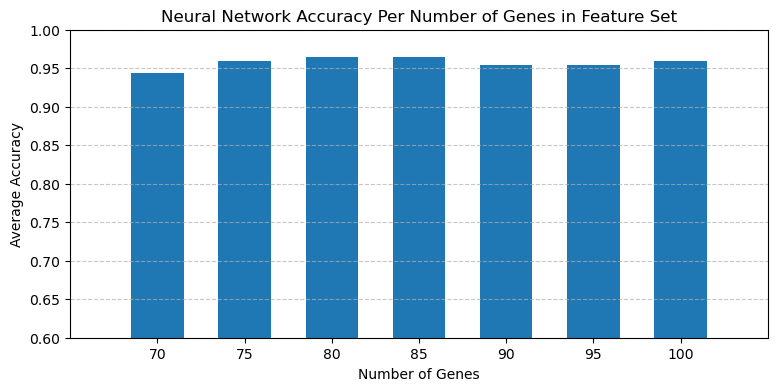

In [838]:
# Plot average accuracy per number of genes selected through RF
num_values = list(acc_dict.keys())
accuracy = [acc_dict[n] for n in numbers]

plt.figure(figsize=(9, 4))
plt.bar(num_values, accuracy,label='Accuracy', width=3)
plt.xlabel('Number of Genes')
plt.ylabel('Average Accuracy')
plt.title('Neural Network Accuracy Per Number of Genes in Feature Set')
plt.xticks(num_values)
plt.ylim(0.60,1.0)
plt.xlim(65,105)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [839]:
# Scale X_train and X_test for use in the final model

final_scaler = MinMaxScaler()

X_train_scaled = pd.DataFrame(
    final_scaler.fit_transform(X_train_raw),
    columns=X_train_raw.columns,
    index=X_train_raw.index)

X_test_scaled = pd.DataFrame(
    final_scaler.transform(X_test_raw),
    columns=X_test_raw.columns,
    index=X_test_raw.index)

# Use the optimal number of genes in the RF to find the final feature set
X_train_final, ids_final = rf_gene_selection(X_train_scaled,y_train,optimal_n)

# Apply the chosen genes to X_test
X_test_final = X_test_scaled[ids_final]

In [865]:
# Create final NN model
final_model = create_nn(input_dim=optimal_n)

# Create a stratified validation split
X_fit_final, X_val_final, y_fit_final, y_val_final = train_test_split(
    X_train_final, y_train, test_size=0.2, random_state=42, stratify=y_train)

# Run the model
final_hist = final_model.fit(X_fit_final,np.asarray(y_fit_final).ravel(),epochs=50,batch_size=5,
                             validation_data=(X_val_final, np.asarray(y_val_final).ravel()),verbose=0)

# Evaluate the final model on the untouched test set
test_loss, test_accuracy = final_model.evaluate(
    X_test_final,
    np.asarray(y_test).ravel(),
    verbose=0)

# Print accuracy and loss
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.20350639522075653
Test Accuracy: 0.9591836929321289


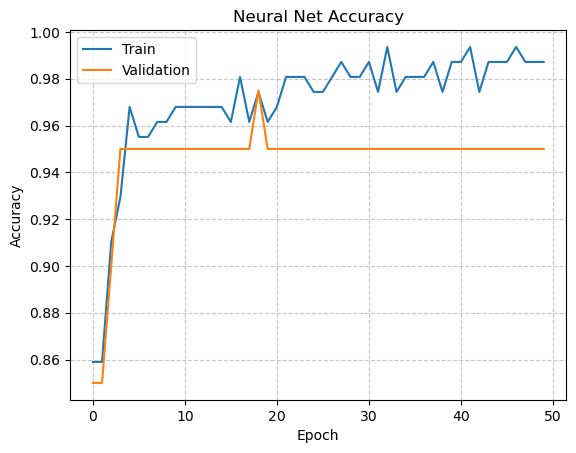

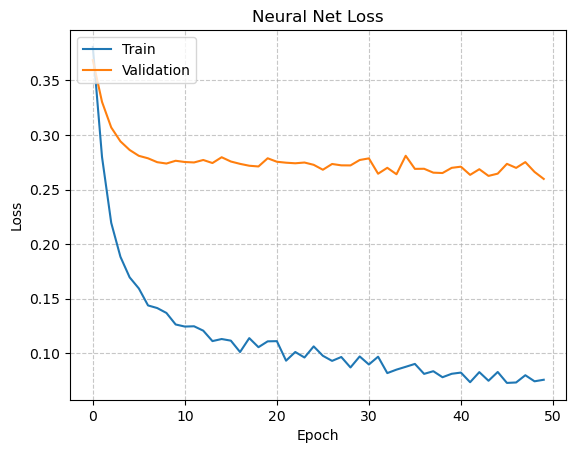

In [866]:
# Plot training & validation accuracy values
plt.plot(final_hist.history['accuracy'])
plt.plot(final_hist.history['val_accuracy'])
plt.title('Neural Net Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
 
# Plot training & validation loss values
plt.plot(final_hist.history['loss'])
plt.plot(final_hist.history['val_loss'])
plt.title('Neural Net Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [867]:
# Predict on test data
pred_prob = final_model.predict(X_test_final)
pred = pred_prob.round().astype(int)
pred_df = pd.DataFrame(pred, columns=['Pred Label'])

# Make results dataframe
y_test_df = pd.DataFrame(y_test.values, columns=['True Label'])
pred_df.reset_index(drop=True, inplace=True)
y_test_df.reset_index(drop=True, inplace=True)
results = pd.concat([pred_df, y_test_df], axis=1)
results.head()

2/2 [==============================] - 0s 3ms/step


,Pred Label,True Label
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0



					FINAL MODEL REPORT
----------------------------------------------------------------------------------------------------
Number of genes in feature set:        
80

Gene Names:        
['CXCL8', 'FPR2', 'S100A8', 'CXCR1', 'C6', 'SLC14A2', 'PYCR1', 'ITIH3', 'IL1B', 'NAMPT', 'WIPF3', nan, 'FCGR3B', 'DUOXA2', 'HOXC11', 'FCGR3A', 'HK2', 'MUC1', nan, 'FCGR1B', 'JADE1', 'CXCL3', 'KAT14', 'AFF2', 'GBP1', 'DRGX', 'CASP1', 'HCAR3', 'ST13', 'PI3', 'PELATON', 'IL15RA', 'LILRB3', 'CXCL5', 'AQP9', 'ZNF395', 'LRG1', 'SLPI', 'SLC28A2', 'APOBEC3A', 'ELL2', 'F7', 'WNT5A', 'CEACAM5', 'S100A12', 'IL1RN', 'SLC39A8', 'IRF1', 'TRHDE-AS1', 'FPR1', 'CXCL16', 'SEMA3E', 'MMP3', 'CSF3R', 'MUC4', 'MMP10', 'PRSS22', 'S100A9', 'FCGR1A', 'C2CD4A', 'NFE2', 'PDZK1IP1', 'KHDRBS2', 'PROK2', 'EML6', 'CEACAM7', 'CYP4A11', 'SLC25A42', nan, 'CLEC4D', 'DNAJC12', 'FAM102A', 'CXCL6', 'OSM', 'NTNG1', 'TGM2', 'CD300E', 'EFR3B', 'TRPC4', 'HSD11B1']

Gene IDs:                       
['ENSG00000169429', 'ENSG00000171049', 'ENS

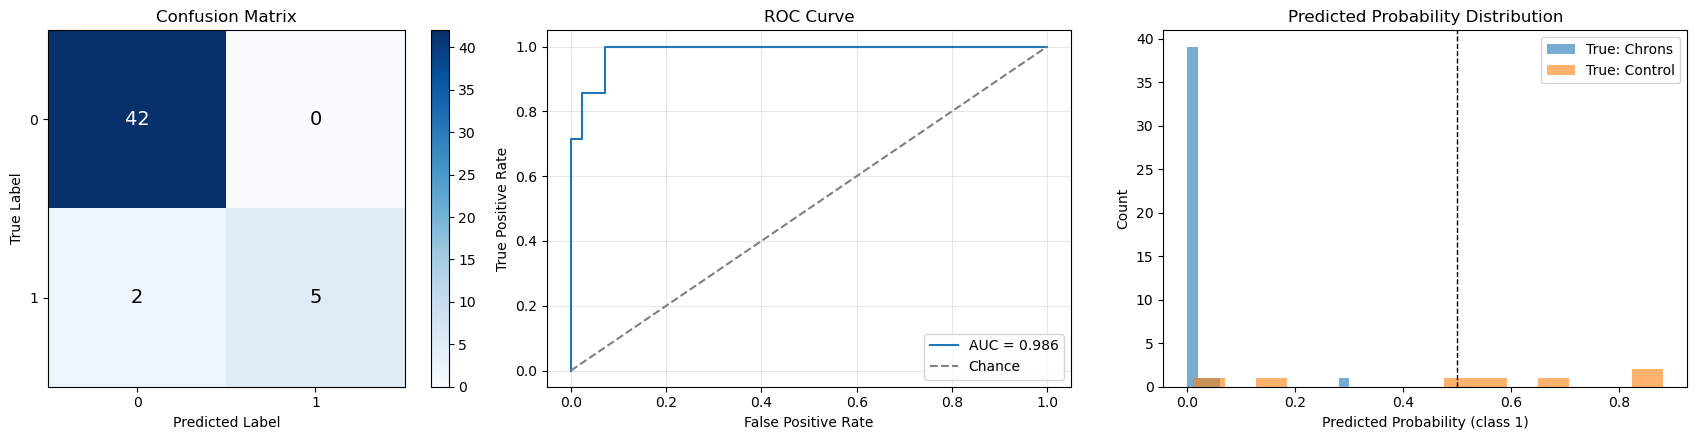

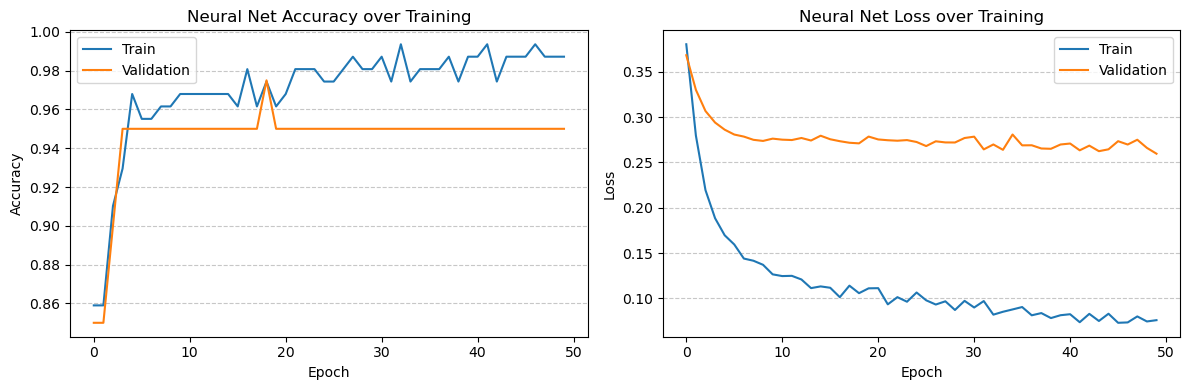

In [868]:
y_test_arr = np.asarray(y_test).ravel()
pred_prob_arr = pred_prob.ravel()
pred_arr = pred.ravel()

final_gene_names = [name_df.loc[id, 'Gene Name'] 
                    if id in name_df.index else 'Unknown'for id in ids_final]

# Compute metrics
acc = accuracy_score(y_test_arr, pred_arr)
bal_acc = balanced_accuracy_score(y_test_arr, pred_arr)
auc = roc_auc_score(y_test_arr, pred_prob_arr)
f1_pos = f1_score(y_test_arr, pred_arr, pos_label=0)
f1_neg = f1_score(y_test_arr, pred_arr, pos_label=1)
majority_baseline = max(y_test_arr.mean(), 1 - y_test_arr.mean())

# Print final model report with all metrics
print("\n\t\t\t\t\tFINAL MODEL REPORT")
print("-"*100)
print(f"Number of genes in feature set:        \n{optimal_n}")
print(f"\nGene Names:        \n{final_gene_names}")
print(f"\nGene IDs:                       \n{ids_final}")
print("-"*100)
print(f"Accuracy:                    {acc:.4f}")
print(f"Majority-class baseline:     {majority_baseline:.4f}")
print(f"Margin over baseline:        {acc - majority_baseline:+.4f}")
print(f"Balanced accuracy:           {bal_acc:.4f}")
print(f"F1 score (positive class):   {f1_pos:.4f}")
print(f"F1 score (negative class):   {f1_neg:.4f}")
print(f"ROC AUC:                     {auc:.4f}")
print("-"*100)
print(classification_report(y_test_arr, pred_arr))
print("-"*100)

# Create a confusion matrix
cm = confusion_matrix(y_test_arr, pred_arr)
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[0].text(j, i, str(cm[i, j]), ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
plt.colorbar(im, ax=axes[0], fraction=0.046)

# Create an ROC Curve
fpr, tpr, _ = roc_curve(y_test_arr, pred_prob_arr)
axes[1].plot(fpr, tpr, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

# Create a predicted probability distribution
axes[2].hist(pred_prob_arr[y_test_arr == 0], bins=15, alpha=0.6, label='True: Chrons')
axes[2].hist(pred_prob_arr[y_test_arr == 1], bins=15, alpha=0.6, label="True: Control")
axes[2].axvline(0.5, color='black', linestyle='--', linewidth=1)
axes[2].set_title('Predicted Probability Distribution')
axes[2].set_xlabel('Predicted Probability (class 1)')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.show()

# Print training curves 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(final_hist.history['accuracy'], label='Train')
axes[0].plot(final_hist.history['val_accuracy'], label='Validation')
axes[0].set_title('Neural Net Accuracy over Training')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

axes[1].plot(final_hist.history['loss'], label='Train')
axes[1].plot(final_hist.history['val_loss'], label='Validation')
axes[1].set_title('Neural Net Loss over Training')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [869]:
input_tensor = tf.convert_to_tensor(X_test_final.values, dtype=tf.float32)
with tf.GradientTape() as tape:
    tape.watch(input_tensor)
    output = final_model(input_tensor)
gradients = tape.gradient(output, input_tensor)
 
# Average absolute gradient across all test samples -> one importance score per gene
feature_importance = np.mean(np.abs(gradients.numpy()), axis=0)
feature_importance = np.nan_to_num(feature_importance, nan=0.0)
 
# Get top most influential genes (by gradient magnitude)
top_n = optimal_n
top_indices = np.argsort(feature_importance)[::-1][:top_n]
top_nn_ids = X_test_final.columns[top_indices].tolist()
importances = feature_importance[top_indices].tolist()
 
top_gene_names = [name_df.loc[gene_id, 'Gene Name'] 
                  if gene_id in name_df.index 
                  else 'Unknown'for gene_id in top_nn_ids]

top_nn_genes_df = pd.DataFrame({
    'Gene ID': top_nn_ids,
    'Gene Name': top_gene_names,
    'Importance Score': importances})

top_nn_genes_df.style.set_caption("Importance Scores of Genes Used in NN Prediction")
 

,Gene ID,Gene Name,Importance Score
0,ENSG00000039537,C6,0.089116
1,ENSG00000143546,S100A8,0.046965
2,ENSG00000124875,CXCL6,0.043904
3,ENSG00000169429,CXCL8,0.043853
4,ENSG00000279487,nan,0.041686
5,ENSG00000162267,ITIH3,0.039774
6,ENSG00000133107,TRPC4,0.036429
7,ENSG00000099985,OSM,0.036086
8,ENSG00000149968,MMP3,0.035354
9,ENSG00000159399,HK2,0.033556
